# Phase 3: Perturbation-Aware Training — Input Per-Spike Jitter (SHD)

Unlike the fixed-weight experiments (train once, evaluate under perturbation), here a
**fresh model is trained for every jitter level**: the train / val / test splits are all
regenerated with per-spike Gaussian jitter of standard deviation $\sigma$ (ms), and the
network is trained and tested on that jittered dataset.

Per-spike jitter shifts each input spike independently by an offset drawn from
$\mathcal{N}(0, \sigma)$, clipped to $[0, T-1]$ and placed at the nearest free time bin,
so per-neuron spike counts are approximately preserved while precise timing is destroyed.
A flat curve therefore indicates a rate-driven solution; a steep drop indicates the model
depends on input spike timing.

Two model variants are compared:
- **SGD-delay** (solid, circles) — SNN with learnable axonal delays.
- **SGD** (dashed, x markers) — baseline SNN without delays.

Three dataset variants: **Whole** (blue, 700 inputs), **Part** (green, 224),
**Norm** (red, 224, rate-normalised).

Source: `jitter/jitter_train.py`, results in `jitter/log/`.

> **Note.** The **Whole x SGD-delay** sweep has not finished — `jitter/data/` only holds
> checkpoints up to $\sigma = 10$ and no results file was written. Every figure below
> renders that combination as an explicit placeholder rather than dropping it silently.

In [1]:
import json
import pathlib
from typing import Optional

import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

LOG_DIR = pathlib.Path("jitter/log")  # notebook lives in perturbation/

# Jitter levels swept by SIGMA_VALUES in jitter_train.py, in ms.
SIGMA_VALUES = [0, 1, 3, 5, 10, 17, 25]

DATASETS = ["whole", "part", "norm"]
DATASET_LABELS = {"whole": "Whole", "part": "Part", "norm": "Norm"}
VARIANTS = [("delay", "SGD-delay"), ("nodelay", "SGD")]

COLORS = {"whole": "#1f77b4", "part": "#2ca02c", "norm": "#d62728"}
LINE_STYLES = {
    "delay": {"marker": "o", "linestyle": "-", "markersize": 5},
    "nodelay": {"marker": "x", "linestyle": "--", "markersize": 6},
}
PLACEHOLDER_GREY = "0.55"


def results_path(dataset: str, variant: str) -> pathlib.Path:
    """Return the sweep-accuracy JSON path for one dataset/model combination.

    Args:
        dataset: Dataset variant key ("whole", "part" or "norm").
        variant: Model variant key ("delay" or "nodelay").

    Returns:
        Path to the results JSON (which may not exist yet).
    """
    return LOG_DIR / f"jitter_{dataset}_{variant}_inputpert_input_perturbation_results.json"


def logs_path(dataset: str, variant: str) -> pathlib.Path:
    """Return the per-sigma training-log JSON path for one combination.

    Args:
        dataset: Dataset variant key ("whole", "part" or "norm").
        variant: Model variant key ("delay" or "nodelay").

    Returns:
        Path to the training-log JSON (which may not exist yet).
    """
    return LOG_DIR / f"jitter_{dataset}_{variant}_inputpert_input_perturbation_training_logs.json"


def load_sweep(dataset: str, variant: str) -> Optional[tuple]:
    """Load the final test accuracy at each jitter level.

    Args:
        dataset: Dataset variant key ("whole", "part" or "norm").
        variant: Model variant key ("delay" or "nodelay").

    Returns:
        Tuple of (sigma values, accuracies in percent), or None when the run has
        not written a results file yet.
    """
    path = results_path(dataset, variant)
    if not path.exists():
        return None
    with open(path) as fh:
        raw = json.load(fh)
    sigmas = sorted(int(key) for key in raw)
    accuracies = np.array([raw[str(sigma)]["accuracy"] for sigma in sigmas]) * 100
    return sigmas, accuracies


def load_training_logs(dataset: str, variant: str) -> Optional[dict]:
    """Load the per-epoch training log of every jitter level.

    Args:
        dataset: Dataset variant key ("whole", "part" or "norm").
        variant: Model variant key ("delay" or "nodelay").

    Returns:
        Mapping "sigma=<value>" -> log dict with epoch / train_loss / val_loss /
        val_acc / delay_mean lists, or None when the run has not written logs yet.
    """
    path = logs_path(dataset, variant)
    if not path.exists():
        return None
    with open(path) as fh:
        return json.load(fh)


def draw_placeholder(ax: plt.Axes, title: str) -> None:
    """Mark an axes as an empty placeholder for a run with no results on disk.

    Tick labels are kept (only greyed) because the panel may be the one that
    carries the shared axis labels for its row or column.

    Args:
        ax: Axes to convert into a placeholder panel.
        title: Panel title to keep, so the grid layout stays readable.
    """
    ax.text(
        0.5, 0.5, "no results yet\n(placeholder)",
        transform=ax.transAxes, ha="center", va="center",
        fontsize=11, color=PLACEHOLDER_GREY, style="italic",
    )
    ax.set_title(title, color=PLACEHOLDER_GREY)
    ax.set_facecolor("0.96")
    ax.tick_params(colors=PLACEHOLDER_GREY)
    for spine in ax.spines.values():
        spine.set_color("0.8")


# Report which combinations are on disk, so the figures below are easy to read.
for dataset in DATASETS:
    for variant, variant_label in VARIANTS:
        status = "found" if results_path(dataset, variant).exists() else "MISSING"
        print(f"{DATASET_LABELS[dataset]:<6} {variant_label:<10} {status}")

Whole  SGD-delay  MISSING
Whole  SGD        found
Part   SGD-delay  found
Part   SGD        found
Norm   SGD-delay  found
Norm   SGD        found


## 3A: Test Accuracy vs Jitter Level

Each point is a separate model trained *and* tested at that jitter level, so the curve
shows how much class information survives in the jittered input rather than how brittle a
single fixed model is. Sigma values are unevenly spaced (0, 1, 3, 5, 10, 17, 25 ms) and
are plotted on a linear axis with ticks at the swept values.

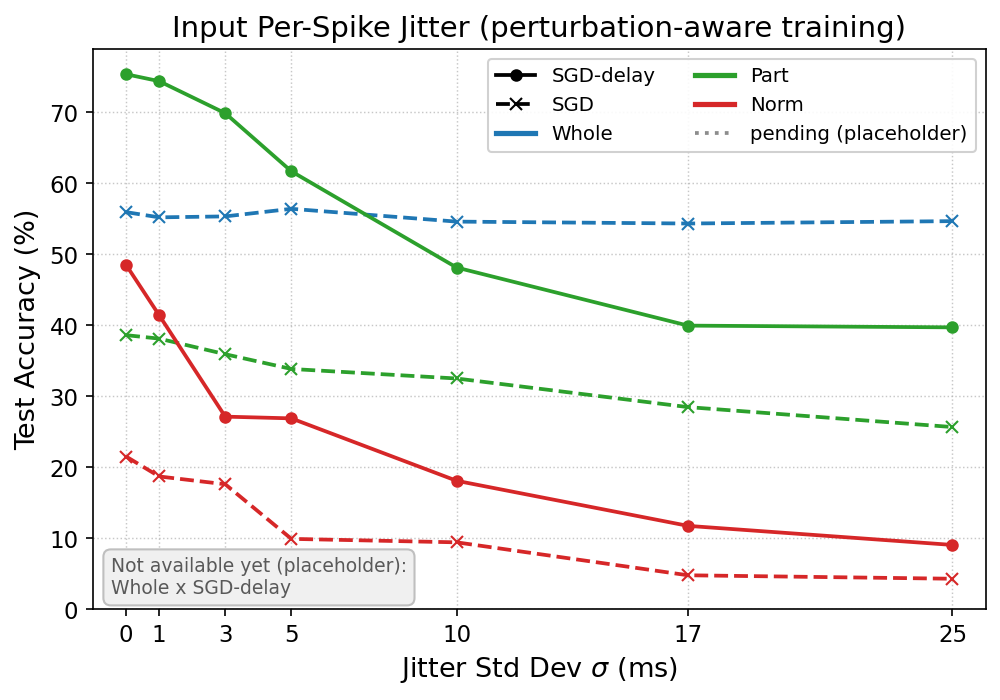

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 4.8))

missing_runs = []
for dataset in DATASETS:
    for variant, variant_label in VARIANTS:
        sweep = load_sweep(dataset, variant)
        if sweep is None:
            missing_runs.append(f"{DATASET_LABELS[dataset]} x {variant_label}")
            continue
        sigmas, accuracies = sweep
        ax.plot(
            sigmas, accuracies,
            color=COLORS[dataset], linewidth=1.8, **LINE_STYLES[variant],
        )

ax.set_title("Input Per-Spike Jitter (perturbation-aware training)")
ax.set_xlabel(r"Jitter Std Dev $\sigma$ (ms)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xticks(SIGMA_VALUES)
ax.set_xlim(-1, 26)
ax.set_ylim(0, None)
ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

# ---------- legend ----------
handles = [
    mlines.Line2D([], [], color="black", linewidth=1.8, label=variant_label,
                  **LINE_STYLES[variant])
    for variant, variant_label in VARIANTS
]
handles += [
    mlines.Line2D([], [], color=COLORS[dataset], linewidth=2.5,
                  label=DATASET_LABELS[dataset])
    for dataset in DATASETS
]
if missing_runs:
    handles.append(
        mlines.Line2D([], [], color=PLACEHOLDER_GREY, linestyle=":", linewidth=1.8,
                      label="pending (placeholder)")
    )
ax.legend(handles=handles, loc="upper right", framealpha=0.9, ncol=2)

# ---------- placeholder note for runs with no results file ----------
if missing_runs:
    ax.text(
        0.02, 0.02,
        "Not available yet (placeholder):\n" + "\n".join(missing_runs),
        transform=ax.transAxes, ha="left", va="bottom", fontsize=9,
        color="0.35",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="0.94", edgecolor="0.75"),
    )

fig.tight_layout()
#plt.savefig("jitter_input_perturbation_results.png", dpi=300, bbox_inches="tight")
plt.show()